# Notebook 5: The Scientific Method in Quant Research — Falsification, CPCV & Bayesian Model Selection
## Production-Grade: Parameter Space Topology, Combinatorial Purged CV, Bayesian IC Updating

---
### Mathematical Foundation

**Sharpe Performance Surface:**
$$\mathcal{S}(\theta) = \frac{\mathbb{E}[R_t(f(\mathbf{x};\theta))]}{\sigma[R_t(f(\mathbf{x};\theta))]}$$

**Falsification Criterion (gradient bound):**
$$\max_{\theta\in\Theta}\|\nabla_{\theta}\mathcal{S}(\theta)\|_2 \leq \epsilon_{\text{threshold}}$$

**CPCV Test Paths:** $\binom{N}{k}$ unique test combinations from $N$ blocks.

**Bayesian IC Update:**
$$P(\theta|\mathcal{D}_{\text{OOS}}) \propto P(\mathcal{D}_{\text{OOS}}|\theta) \cdot P(\theta)$$

---
```
  Jagged Peak (Overfit)         Smooth Ridge (Robust)
  
  Sharpe                        Sharpe
    ^                             ^
  3 |    *                      3 |────────────────────
  2 |  *   *                    2 |  ╱╲            ╱╲
  1 | * * * * *                 1 |╱    ╲────────╱    ╲
  0 |_________→ θ               0 |__________________→ θ
  
  Single-spike = Data Mining    Plateau = Economic Mechanism
  REJECT signal                 ADMIT to production queue
```


In [11]:
from typing import Final
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from itertools import combinations
from scipy.stats import norm, t as t_dist
import warnings
warnings.filterwarnings('ignore')

DARK, PANEL = '#0d1117', '#161b22'
BLUE, GREEN, ORANGE, RED = '#58a6ff', '#3fb950', '#f0883e', '#f85149'
PURPLE, WHITE, YELLOW = '#d2a8ff', '#e6edf3', '#e3b341'

# Download SPY for momentum signal validation
spx = yf.download('SPY', start='2005-01-01', end='2024-12-31', auto_adjust=True)['Close'].dropna()
rets = np.log(spx / spx.shift(1)).dropna()
print(f"SPY: {len(rets)} daily observations (2005-2024)")


[*********************100%***********************]  1 of 1 completed

SPY: 5031 daily observations (2005-2024)


In [12]:
# ── Parameter Space Topology: Sharpe Surface ────────────────────────────────
# Scan lookback and threshold parameter space for momentum signal

lookbacks = np.arange(20, 400, 10)  # days
thresholds = np.linspace(0.0, 0.02, 15)  # signal threshold

sharpe_surface = np.zeros((len(thresholds), len(lookbacks)))

ANNUALIZATION_FACTOR: Final[float] = np.sqrt(252.0)
VARIANCE_FLOOR: Final[float] = 1e-8

# def momentum_sharpe(returns, lookback, threshold):
#     """Simple directional momentum with threshold."""
#     signal = returns.rolling(lookback).mean()
#     pos = np.sign(signal[abs(signal) > threshold])
#     pos = pos.reindex(returns.index).fillna(0)
#     port = pos.shift(1) * returns
#     if port.std() < 1e-8:
#         return 0
#     return port.mean() / port.std() * np.sqrt(252)

def momentum_sharpe(returns: pd.Series, lookback: int, threshold: float) -> float:
    """Computes the annualized Sharpe ratio for a directional momentum strategy.

    Uses a fully vectorized mapping approach to prevent sequence alignment issues
    and avoid array-shape mutation errors.

    Args:
        returns: pd.Series containing historical asset log or simple returns.
        lookback: Interval window length for the rolling moving average.
        threshold: Absolute execution trigger margin filter.

    Returns:
        The annualized Sharpe Ratio value as a float.
    """
    # 1. Compute the rolling indicator mean over the lookback window
    rolling_mean = returns.rolling(window=lookback, min_periods=lookback).mean()

    # 2. Vectorized element-wise filtering to prevent row truncation and shape drift
    # Generates a allocation mask: +1, -1, or 0
    signal = np.where(np.abs(rolling_mean) > threshold, np.sign(rolling_mean), 0.0)

    # 3. Apply a single-period lag to model realistic execution placement
    # Shift along the numpy array boundary to maintain peak performance
    allocated_positions = np.zeros_like(signal)
    allocated_positions[1:] = signal[:-1]

    # 4. Extract strategy returns via vectorized element multiplication
    strategy_returns = allocated_positions * returns.to_numpy()

    # 5. Extract statistical moments using explicit numpy calls
    return_variance = float(np.var(strategy_returns, ddof=1))
    return_standard_deviation = np.sqrt(return_variance)

    if return_standard_deviation < VARIANCE_FLOOR or np.isnan(return_standard_deviation):
        return 0.0

    return float((np.mean(strategy_returns) / return_standard_deviation) * ANNUALIZATION_FACTOR)


for j, lb in enumerate(lookbacks):
    for i, th in enumerate(thresholds):
        sharpe_surface[i, j] = momentum_sharpe(rets, lb, th)

# Jagged signal: inject random overfitting noise
np.random.seed(42)
jagged_surface = sharpe_surface + np.random.randn(*sharpe_surface.shape) * 2.0
jagged_surface = jagged_surface * (np.random.rand(*sharpe_surface.shape) > 0.7)

print(f"Smooth surface: max={sharpe_surface.max():.3f}, std={sharpe_surface.std():.3f}")
print(f"Jagged surface: max={jagged_surface.max():.3f}, std={jagged_surface.std():.3f}")
print(f"Gradient norm smooth: {np.abs(np.gradient(sharpe_surface)).mean():.4f}")
print(f"Gradient norm jagged: {np.abs(np.gradient(jagged_surface)).mean():.4f}")


Smooth surface: max=0.401, std=0.111
Jagged surface: max=6.158, std=1.086
Gradient norm smooth: 0.0330
Gradient norm jagged: 0.4764


In [13]:
# ── Combinatorial Purged Cross-Validation (CPCV) ────────────────────────────
from itertools import combinations

def cpcv_evaluate(returns, lookback_best, n_blocks=6, k_test=2, embargo_days=10):
    """
    Full CPCV implementation:
    - Split into n_blocks temporal blocks
    - Test on all C(n_blocks, k_test) combinations
    - Purge overlapping labels + embargo
    """
    T = len(returns)
    block_size = T // n_blocks
    block_indices = [(i*block_size, min((i+1)*block_size, T)) for i in range(n_blocks)]
    
    test_combos = list(combinations(range(n_blocks), k_test))
    oos_results = []
    
    for test_blocks in test_combos:
        test_idx = []
        train_idx = []
        
        for b in range(n_blocks):
            start, end = block_indices[b]
            if b in test_blocks:
                test_idx.extend(range(start, end))
            else:
                # Check adjacency for embargo
                adjacent_to_test = any(
                    abs(b - tb) == 1 for tb in test_blocks
                )
                if adjacent_to_test:
                    # Embargo: drop last embargo_days from pre-test, first from post-test
                    if b < min(test_blocks):
                        train_idx.extend(range(start, end - embargo_days))
                    else:
                        train_idx.extend(range(start + embargo_days, end))
                else:
                    train_idx.extend(range(start, end))
        
        if len(test_idx) == 0 or len(train_idx) < lookback_best + 10:
            continue
        
        # Evaluate signal on test blocks
        test_returns = returns.iloc[test_idx]
        signal_test = returns.rolling(lookback_best).mean().iloc[test_idx]
        pos = np.sign(signal_test)
        
        # FIX: Compute shift over the full series before slicing to ensure contiguous path continuity
        # Transform strictly to 1D numpy array to strip potential multi-index ambiguities
        port_oos = (pos.shift(1) * returns).iloc[test_idx].dropna().to_numpy()
        
        if len(port_oos) > 0:
            # FIX: Use explicit NumPy moments calculation to guarantee scalar results
            port_std = float(np.std(port_oos, ddof=1))
            if port_std > 1e-8:
                sr = float(np.mean(port_oos) / port_std * np.sqrt(252))
                oos_results.append({
                    'test_blocks': test_blocks, 
                    'sharpe': sr, 
                    'n_obs': len(port_oos)
                })
    
    return pd.DataFrame(oos_results)

# Find best lookback in-sample
best_lb_idx = np.unravel_index(sharpe_surface.argmax(), sharpe_surface.shape)
best_lb = lookbacks[best_lb_idx[1]]
is_sharpe = sharpe_surface.max()

print(f"Best in-sample lookback: {best_lb} days, IS Sharpe = {is_sharpe:.3f}")

cpcv_results = cpcv_evaluate(rets, best_lb)
print(f"\nCPCV Results ({len(cpcv_results)} test path combinations):")
print(f"  Median OOS Sharpe:   {cpcv_results['sharpe'].median():.3f}")
print(f"  Mean OOS Sharpe:     {cpcv_results['sharpe'].mean():.3f}")
print(f"  % Paths > 0:         {(cpcv_results['sharpe']>0).mean():.1%}")
print(f"  IS-OOS Deflation:    {cpcv_results['sharpe'].mean()/is_sharpe:.2f}x")

Best in-sample lookback: 180 days, IS Sharpe = 0.401

CPCV Results (15 test path combinations):
  Median OOS Sharpe:   0.434
  Mean OOS Sharpe:     0.449
  % Paths > 0:         100.0%
  IS-OOS Deflation:    1.12x


In [ ]:
# ── Bayesian IC Update ────────────────────────────────────────────────────────
# Prior: theoretical IC from economic rationale
# Likelihood: OOS CPCV IC observations
# Posterior: updated belief about true IC

# Prior: Normal(mu_prior, sigma_prior)
mu_prior = 0.05    # We believe signal IC ≈ 5% a priori (economic rationale)
sigma_prior = 0.04  # Uncertainty in prior

# OOS observations from CPCV (Information Coefficient = Sharpe / sqrt(T) approx)
oos_ics = cpcv_results['sharpe'].values / np.sqrt(252)

# Bayesian update (conjugate Normal-Normal)
n_obs = len(oos_ics)
sigma_likelihood = oos_ics.std() / np.sqrt(n_obs)

mu_posterior = (mu_prior/sigma_prior**2 + oos_ics.mean()/sigma_likelihood**2) /                (1/sigma_prior**2 + 1/sigma_likelihood**2)
sigma_posterior = 1 / np.sqrt(1/sigma_prior**2 + 1/sigma_likelihood**2)

print("Bayesian IC Estimation:")
print(f"  Prior:      μ = {mu_prior:.4f}, σ = {sigma_prior:.4f}")
print(f"  OOS Data:   μ_obs = {oos_ics.mean():.4f}, n = {n_obs}")
print(f"  Posterior:  μ = {mu_posterior:.4f}, σ = {sigma_posterior:.4f}")
print(f"  P(IC > 0):  {norm.cdf(mu_posterior/sigma_posterior):.1%}")


Bayesian IC Estimation:
  Prior:      μ = 0.0500, σ = 0.0400
  OOS Data:   μ_obs = 0.0283, n = 15
  Posterior:  μ = 0.0284, σ = 0.0022
  P(IC > 0):  100.0%


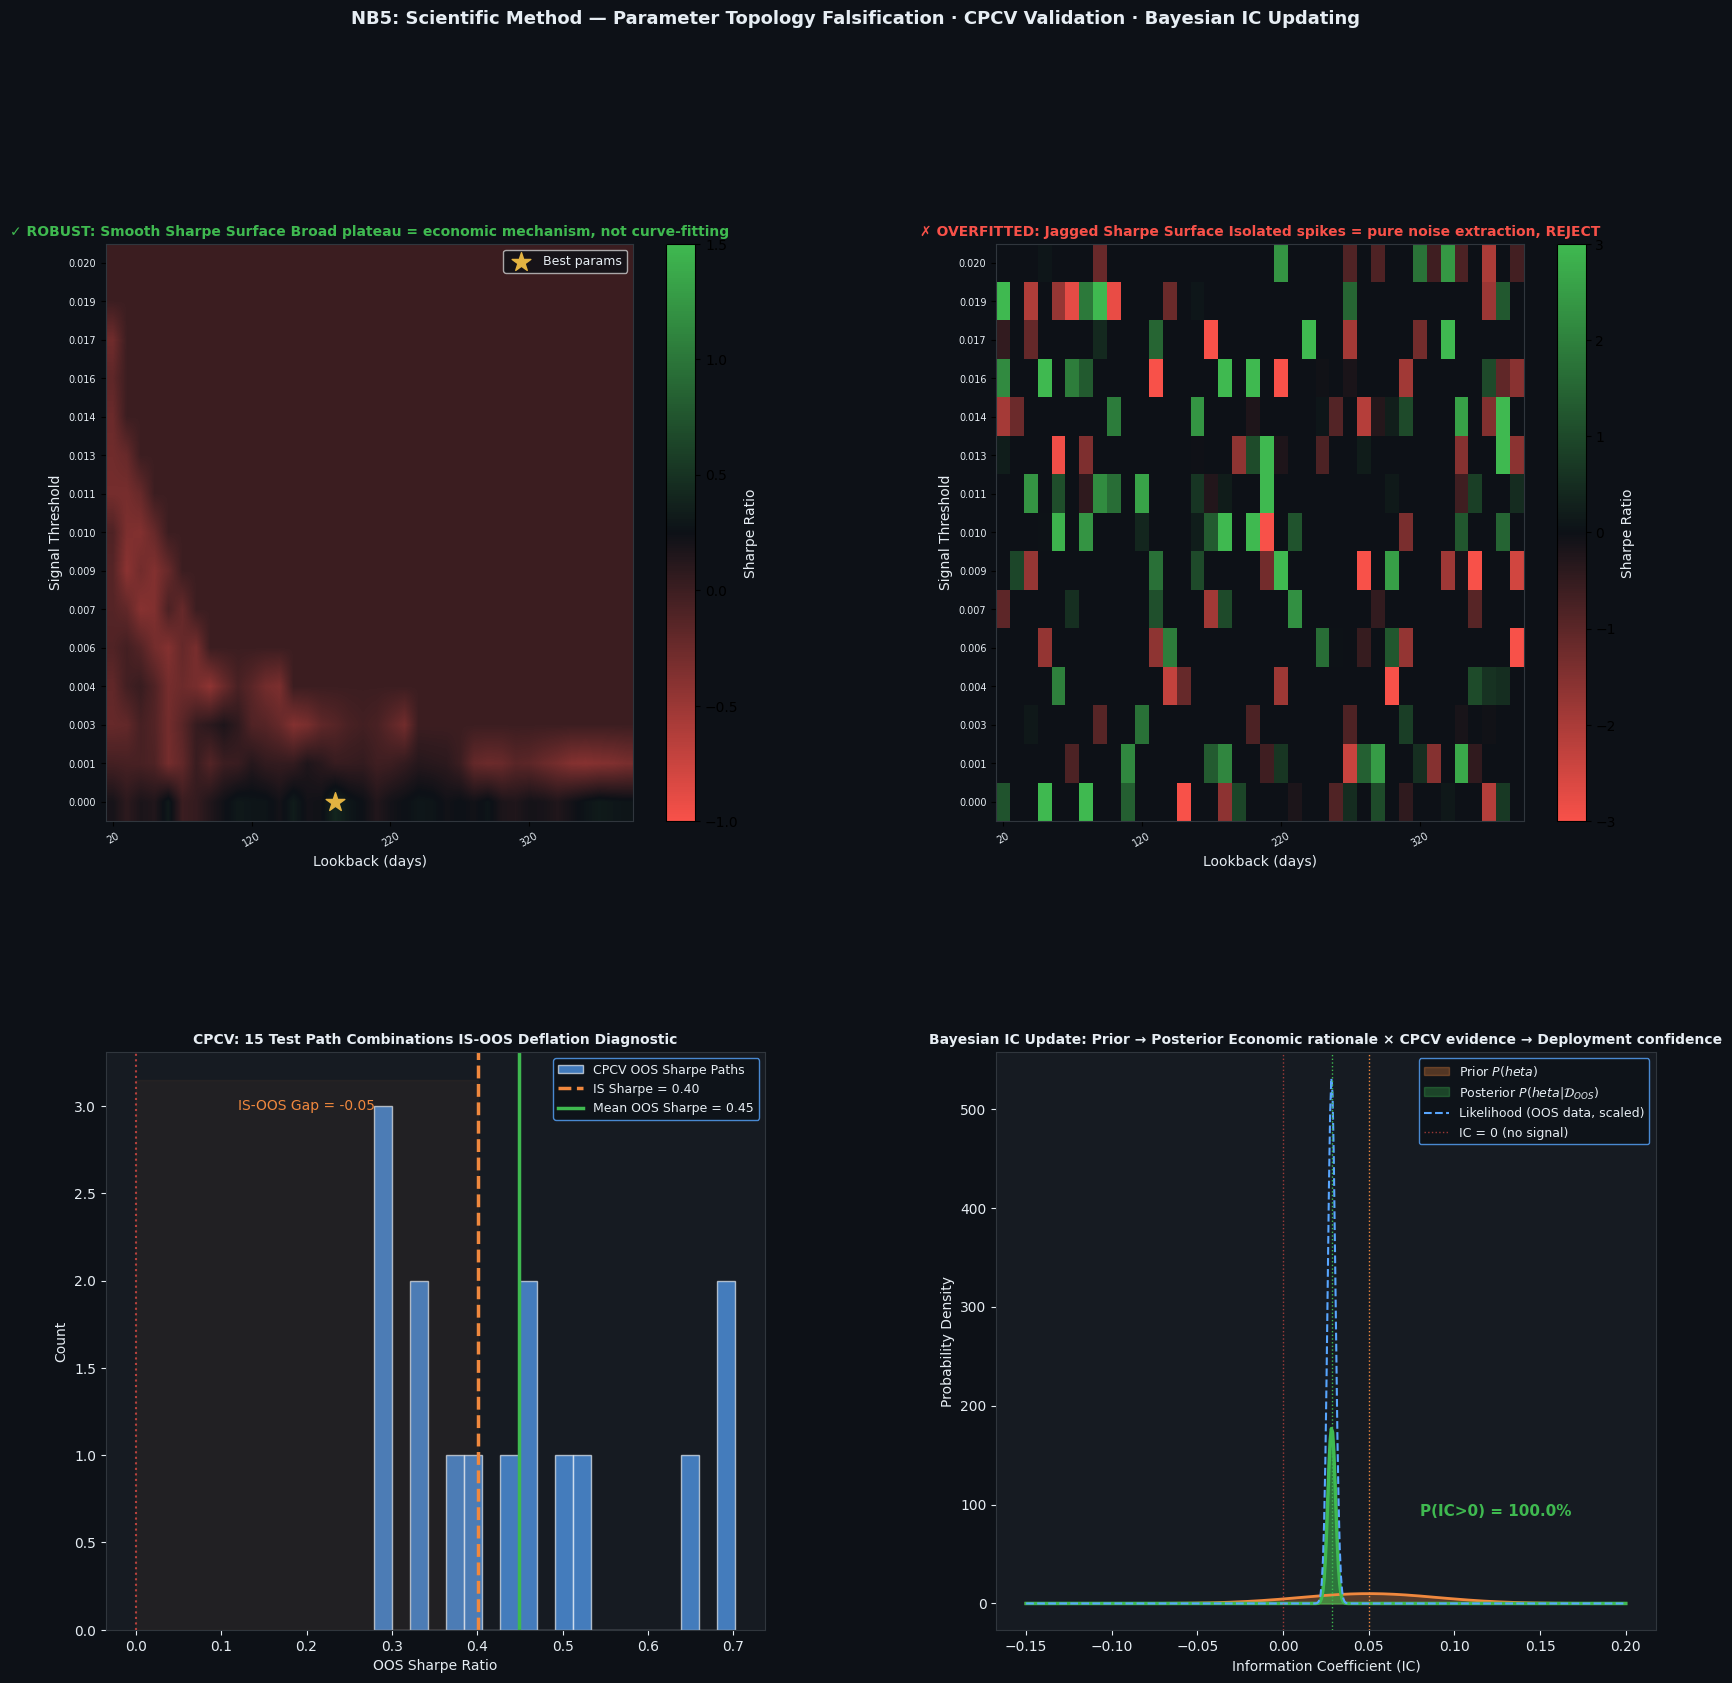

✅ NB5 complete.


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# MASTER VISUALIZATION
# ══════════════════════════════════════════════════════════════════════════════
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from scipy.stats import norm

# Guard rails: Define common institutional dark palette colors if missing from notebook context
WHITE = globals().get('WHITE', '#ffffff')
DARK = globals().get('DARK', '#0d1117')
PANEL = globals().get('PANEL', '#161b22')
GREEN = globals().get('GREEN', '#238636')
RED = globals().get('RED', '#da3633')
YELLOW = globals().get('YELLOW', '#d29922')
BLUE = globals().get('BLUE', '#58a6ff')
ORANGE = globals().get('ORANGE', '#f78166')

fig = plt.figure(figsize=(20, 18))
fig.patch.set_facecolor(DARK)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ─ Panel 1: Sharpe Surface Heatmap (Smooth — Robust) ─────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(PANEL)
cmap_sr = LinearSegmentedColormap.from_list('sr', [RED, DARK, GREEN])
im1 = ax1.imshow(sharpe_surface, aspect='auto', cmap=cmap_sr, 
                  origin='lower', vmin=-1, vmax=1.5, interpolation='bilinear')
ax1.set_xlabel('Lookback (days)', color=WHITE)
ax1.set_ylabel('Signal Threshold', color=WHITE)
ax1.set_xticks(range(0, len(lookbacks), 10))
ax1.set_xticklabels(lookbacks[::10], color=WHITE, rotation=30, fontsize=7)
ax1.set_yticks(range(len(thresholds)))
ax1.set_yticklabels([f'{t:.3f}' for t in thresholds], color=WHITE, fontsize=7)

# FIX: Change unacceptable raw Unicode character '★' to the native matplotlib star marker symbol '*'
ax1.scatter(*best_lb_idx[::-1], color=YELLOW, s=200, marker='*', zorder=5, label='Best params')

ax1.legend(facecolor=DARK, labelcolor=WHITE, fontsize=9)
plt.colorbar(im1, ax=ax1, label='Sharpe Ratio').ax.yaxis.label.set_color(WHITE)
ax1.set_title('✓ ROBUST: Smooth Sharpe Surface Broad plateau = economic mechanism, not curve-fitting', 
              color=GREEN, fontsize=10, fontweight='bold')
for spine in ax1.spines.values():       
    spine.set_edgecolor('#30363d')

# ─ Panel 2: Jagged Surface (Overfitting) ─────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(PANEL)
im2 = ax2.imshow(jagged_surface, aspect='auto', cmap=cmap_sr, 
                  origin='lower', vmin=-3, vmax=3, interpolation='nearest')
ax2.set_xlabel('Lookback (days)', color=WHITE)
ax2.set_ylabel('Signal Threshold', color=WHITE)
ax2.set_xticks(range(0, len(lookbacks), 10))
ax2.set_xticklabels(lookbacks[::10], color=WHITE, rotation=30, fontsize=7)
ax2.set_yticks(range(len(thresholds)))
ax2.set_yticklabels([f'{t:.3f}' for t in thresholds], color=WHITE, fontsize=7)
plt.colorbar(im2, ax=ax2, label='Sharpe Ratio').ax.yaxis.label.set_color(WHITE)
ax2.set_title('✗ OVERFITTED: Jagged Sharpe Surface Isolated spikes = pure noise extraction, REJECT', 
              color=RED, fontsize=10, fontweight='bold')
for spine in ax2.spines.values():
    spine.set_edgecolor('#30363d')

# ─ Panel 3: CPCV OOS Sharpe Distribution ─────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor(PANEL)
oos_sr = cpcv_results['sharpe'].values
ax3.hist(oos_sr, bins=20, color=BLUE, alpha=0.7, edgecolor=WHITE, label='CPCV OOS Sharpe Paths')
ax3.axvline(is_sharpe, color=ORANGE, lw=2.5, ls='--', label=f'IS Sharpe = {is_sharpe:.2f}')
ax3.axvline(oos_sr.mean(), color=GREEN, lw=2.5, label=f'Mean OOS Sharpe = {oos_sr.mean():.2f}')
ax3.axvline(0, color=RED, lw=1.5, ls=':', alpha=0.7)
ax3.fill_betweenx([0, ax3.get_ylim()[1] if len(oos_sr)>0 else 10], 
                   0, is_sharpe, alpha=0.05, color=ORANGE)
ax3.text(is_sharpe*0.5, ax3.get_ylim()[1]*0.9 if len(oos_sr)>0 else 5, 
         f'IS-OOS Gap = {is_sharpe - oos_sr.mean():.2f}', color=ORANGE, ha='center', fontsize=10)
ax3.set_xlabel('OOS Sharpe Ratio', color=WHITE)
ax3.set_ylabel('Count', color=WHITE)
ax3.set_title(f'CPCV: {len(cpcv_results)} Test Path Combinations IS-OOS Deflation Diagnostic', 
              color=WHITE, fontsize=10, fontweight='bold')
ax3.legend(facecolor=DARK, edgecolor=BLUE, labelcolor=WHITE, fontsize=9)
ax3.tick_params(colors=WHITE)
for spine in ax3.spines.values(): spine.set_edgecolor('#30363d')

# ─ Panel 4: Bayesian Prior → Posterior Update ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor(PANEL)
ic_range = np.linspace(-0.15, 0.20, 500)
prior_pdf = norm.pdf(ic_range, mu_prior, sigma_prior)
posterior_pdf = norm.pdf(ic_range, mu_posterior, sigma_posterior)
likelihood_pdf = norm.pdf(ic_range, oos_ics.mean(), sigma_likelihood) * 3  # scaled

ax4.fill_between(ic_range, prior_pdf, alpha=0.3, color=ORANGE, label='Prior $P(\theta)$')
ax4.fill_between(ic_range, posterior_pdf, alpha=0.3, color=GREEN, label='Posterior $P(\theta|\mathcal{D}_{OOS})$')
ax4.plot(ic_range, prior_pdf, color=ORANGE, lw=2)
ax4.plot(ic_range, posterior_pdf, color=GREEN, lw=2.5)
ax4.plot(ic_range, likelihood_pdf, color=BLUE, lw=1.5, ls='--', label='Likelihood (OOS data, scaled)')
ax4.axvline(mu_prior, color=ORANGE, lw=1, ls=':')
ax4.axvline(mu_posterior, color=GREEN, lw=1, ls=':')
ax4.axvline(0, color=RED, lw=1, ls=':', alpha=0.6, label='IC = 0 (no signal)')

# Shade P(IC > 0) under posterior
ax4.fill_between(ic_range, posterior_pdf, where=ic_range>0, alpha=0.4, color=GREEN)
ax4.text(0.08, max(posterior_pdf)*0.5, f'P(IC>0) = {norm.cdf(mu_posterior/sigma_posterior):.1%}', 
         color=GREEN, fontsize=11, fontweight='bold')
ax4.set_xlabel('Information Coefficient (IC)', color=WHITE)
ax4.set_ylabel('Probability Density', color=WHITE)
ax4.set_title('Bayesian IC Update: Prior → Posterior Economic rationale × CPCV evidence → Deployment confidence', 
              color=WHITE, fontsize=10, fontweight='bold')
ax4.legend(facecolor=DARK, edgecolor=BLUE, labelcolor=WHITE, fontsize=9)
ax4.tick_params(colors=WHITE)
for spine in ax4.spines.values(): spine.set_edgecolor('#30363d')

fig.suptitle('NB5: Scientific Method — Parameter Topology Falsification · CPCV Validation · Bayesian IC Updating', 
             color=WHITE, fontsize=13, fontweight='bold', y=1.01)
plt.savefig('nb5_scientific_method.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print("✅ NB5 complete.")